# 🧪 Week 4 · Day 1 — Train / Validation / Test Splits
**BinX Tech — AI & Machine Learning Internship** 🚀

## 🎯 Learning Objectives
- 🧠 Explain why a validation set is needed in addition to a test set.
- ✂️ Create a correct three-way split in Scikit-learn.
- 🚫 Explain why tuning against the test set produces misleading results.

## 🧭 Today's Hands-On Lab
1. 📦 Take a dataset and create a 60/20/20 train/validation/test split with a fixed `random_state`.
2. 🏋️ Train a model on the training set and tune **one** setting by checking the validation set only.
3. 🏁 Evaluate the final model on the test set **exactly once** and report the score.
4. ✍️ In Markdown, explain what would go wrong if you had tuned against the test set instead.

> 💡 **Note:** This notebook uses the scikit-learn Breast Cancer dataset as a stand-in for your Week 3 dataset.
> If you already have your own Week 3 dataset (CSV), replace the "Load Data" cell below with your own loading code — the rest of the workflow stays exactly the same.


## 0️⃣ Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42


## 1️⃣ Load Data 📊
Replace this cell with `pd.read_csv("your_week3_dataset.csv")` if you have your own file.
For now we use a built-in classification dataset so the notebook runs end-to-end immediately.


In [2]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())
X.head()


X shape: (569, 30)
y distribution:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 🎨 Quick Look — Class Balance

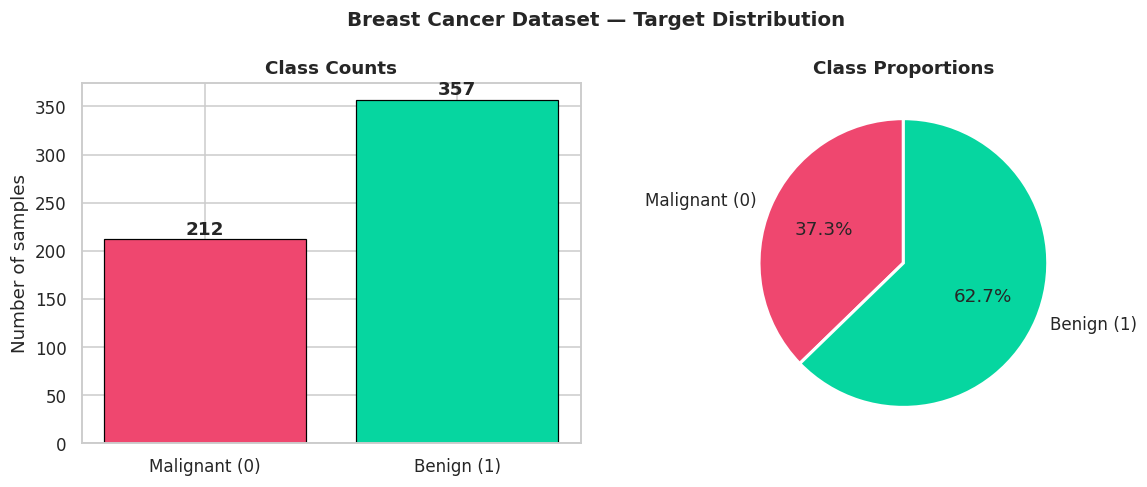

In [3]:
class_counts = y.value_counts().sort_index()
labels = ["Malignant (0)", "Benign (1)"]
colors = ["#ef476f", "#06d6a0"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(labels, class_counts.values, color=colors, edgecolor="black", linewidth=0.8)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")
axes[0].set_title("Class Counts", fontweight="bold")
axes[0].set_ylabel("Number of samples")

axes[1].pie(class_counts.values, labels=labels, autopct="%1.1f%%", colors=colors,
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportions", fontweight="bold")

plt.suptitle("Breast Cancer Dataset — Target Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 2️⃣ Step 1 — Build the Three-Way Split (60/20/20) ✂️

Remember the rule: carve off the **test set first** 🔒, then split what remains into train/validation.


In [4]:
# 1) hold out 20% as the final test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# 2) split the rest into train (75% of remaining = 60% of total) and validation (25% of remaining = 20% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"🏋️ Train: {X_train.shape[0]} rows ({X_train.shape[0]/len(X):.0%})")
print(f"🧪 Val:   {X_val.shape[0]} rows ({X_val.shape[0]/len(X):.0%})")
print(f"🏁 Test:  {X_test.shape[0]} rows ({X_test.shape[0]/len(X):.0%})")


🏋️ Train: 341 rows (60%)
🧪 Val:   114 rows (20%)
🏁 Test:  114 rows (20%)


### 📐 Visualizing the Split

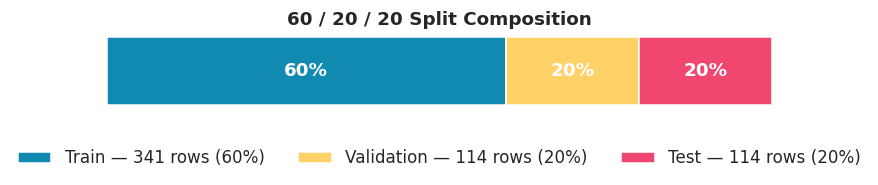

In [5]:
split_names = ["Train", "Validation", "Test"]
split_sizes = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
split_colors = ["#118ab2", "#ffd166", "#ef476f"]

fig, ax = plt.subplots(figsize=(8, 2.2))
left = 0
total = sum(split_sizes)
for name, size, color in zip(split_names, split_sizes, split_colors):
    pct = size / total
    ax.barh(0, pct, left=left, color=color, edgecolor="white", height=0.6,
            label=f"{name} — {size} rows ({pct:.0%})")
    ax.text(left + pct / 2, 0, f"{pct:.0%}", ha="center", va="center",
            fontweight="bold", color="white")
    left += pct

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("60 / 20 / 20 Split Composition", fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False)
plt.tight_layout()
plt.show()


## 3️⃣ Step 2 — Train a Model and Tune ONE Setting Using the Validation Set Only 🎛️

We'll train a `RandomForestClassifier` 🌳 and try a couple of values for `max_depth`,
checking performance on the **validation set** 🧪 — the test set stays untouched 🔒.


In [6]:
candidate_depths = [3, 5, 10, None]
val_scores = {}

for depth in candidate_depths:
    model = RandomForestClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    score = f1_score(y_val, val_pred)
    val_scores[depth] = score
    print(f"max_depth={depth}\t validation F1 = {score:.4f}")

best_depth = max(val_scores, key=val_scores.get)
print(f"\n🏆 Best max_depth based on validation set: {best_depth}")


max_depth=3	 validation F1 = 0.9650
max_depth=5	 validation F1 = 0.9577


max_depth=10	 validation F1 = 0.9650
max_depth=None	 validation F1 = 0.9650

🏆 Best max_depth based on validation set: 3


### 📈 Validation F1 by `max_depth`

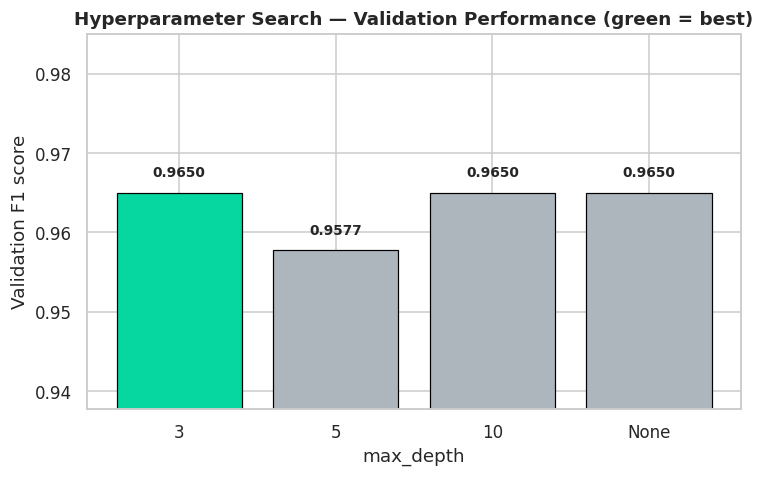

In [7]:
depth_labels = [str(d) for d in val_scores.keys()]
scores = list(val_scores.values())
bar_colors = ["#06d6a0" if d == best_depth else "#adb5bd" for d in val_scores.keys()]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(depth_labels, scores, color=bar_colors, edgecolor="black", linewidth=0.8)

for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.002, f"{score:.4f}",
            ha="center", fontweight="bold", fontsize=9)

ax.set_ylim(min(scores) - 0.02, max(scores) + 0.02)
ax.set_xlabel("max_depth")
ax.set_ylabel("Validation F1 score")
ax.set_title("Hyperparameter Search — Validation Performance (green = best)", fontweight="bold")
plt.tight_layout()
plt.show()


## 4️⃣ Step 3 — Evaluate the FINAL Model on the Test Set (Exactly Once) 🏁

Now that `max_depth` is chosen, retrain on train data with that setting and check the test set —
this is the **one and only time** ☝️ we touch it.


In [8]:
final_model = RandomForestClassifier(max_depth=best_depth, random_state=RANDOM_STATE)
final_model.fit(X_train, y_train)

test_pred = final_model.predict(X_test)
test_f1 = f1_score(y_test, test_pred)
test_acc = accuracy_score(y_test, test_pred)

print(f"✅ Final model (max_depth={best_depth})")
print(f"🎯 Test F1 score:       {test_f1:.4f}")
print(f"🎯 Test accuracy score: {test_acc:.4f}")


✅ Final model (max_depth=3)
🎯 Test F1 score:       0.9583
🎯 Test accuracy score: 0.9474


### 🔍 Confusion Matrix — Final Test Performance

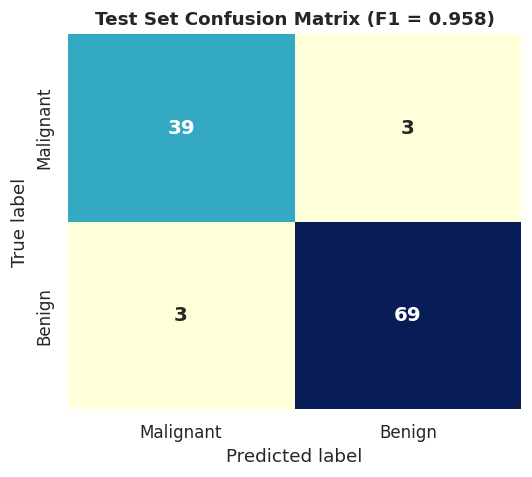

In [9]:
cm = confusion_matrix(y_test, test_pred)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=False,
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"],
            annot_kws={"fontsize": 13, "fontweight": "bold"}, ax=ax)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Test Set Confusion Matrix (F1 = {test_f1:.3f})", fontweight="bold")
plt.tight_layout()
plt.show()


## 5️⃣ Step 4 — Reflection (Markdown) ✍️

**Write your own answer here.** Guiding questions:

- ⚠️ What would have happened to your reported score if you had tuned `max_depth` by checking
  the *test set* instead of the validation set?
- 👀 Why does "peeking" at the test set repeatedly make it stop being an honest estimate?
- ⚖️ How did the validation-selected `max_depth` compare to the other candidates you tried?

*(Replace this text with your own written answer — this is one of the graded deliverables.)*


## ✅ Deliverable Checklist (Day 1)
- [ ] ✂️ 60/20/20 split created with a fixed `random_state`
- [ ] 🎛️ One hyperparameter tuned using the validation set only
- [ ] 🏁 Test set evaluated exactly once, at the end
- [ ] ✍️ Markdown reflection written in your own words
- [ ] 🚀 Notebook committed to GitHub with a clear commit message
